# <p style="text-align: center;"> Customer Churn Prediction Using Machine Learning</p>

### <p style="text-align: center;">Capstone Project 2</p>

### Objective:
The objective of this project is to develop a machine learning model to predict customer churn in a telecom company using the IBM Telco Customer Churn dataset.

The goals of this project are:

* Identify customers likely to churn

* Understand key churn drivers

* Improve customer retention strategies

* Reduce revenue loss

### Dataset Description:
The dataset contains telecom customer information including:

* Demographics

* Service usage

* Billing information

* Customer satisfaction

Total Records: 7043
Total Features: 50 (before cleaning)

### Importing Basic Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Loading Data

In [ ]:
df = pd.read_csv("../data/telco.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

Observation:
* The dataset is largely complete, with missing values appearing only in Offer, Internet Type, Churn Category, and Churn Reason. 
* The null values in churn-related columns likely correspond to customers who have not churned, indicating business-driven missing data rather than random gaps. 
* Similarly, missing entries in Offer and Internet Type may reflect customers who were not assigned an offer or do not use internet services. 
* These patterns suggest that logical handling based on customer status is more appropriate than simple imputation to maintain analytical accuracy.

### Handling Missing Values

In [ ]:
# Finding if the NaN values in the column Interntet type have some meaning or not
df[df["Internet Service"] == "No"]["Internet Type"].value_counts(dropna=False)

Internet Type
NaN    1526
Name: count, dtype: int64

Observation:

* When Internet Service == "No", we see Internet Type = NaN

* This is not real missing data. It simply means customer does not have internet service. 

Action: 

* Replacing NaN values with "No internet"

In [ ]:
df["Offer"].value_counts(dropna=False)

Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

Observation:

* 3877 customers have NaN.

* This likely means: No promotional offer was applied. So we can just infer that they didn't get an offer

Action:

* Replacing NaN values to "No offer"

In [ ]:
df["Internet Type"] = df["Internet Type"].fillna("No Internet")
df["Offer"] = df["Offer"].fillna("No Offer")

In [ ]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

### Dealing with Leakage Columns

We now remove columns that:

* Directly reveal churn outcome
* Are post-event information
* Cannot be known before churn happens

In [ ]:
df.drop(columns=[
    "Customer ID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Churn Category",
    "Churn Reason",
    "Customer Status",
    "Churn Score"
], inplace=True)

In [ ]:
df.shape

(7043, 39)

In [ ]:
df.isnull().sum()

Gender                               0
Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
Population                           0
Quarter                              0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music          

Note: Successfully dealt with missing values

In [ ]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Performing EDA

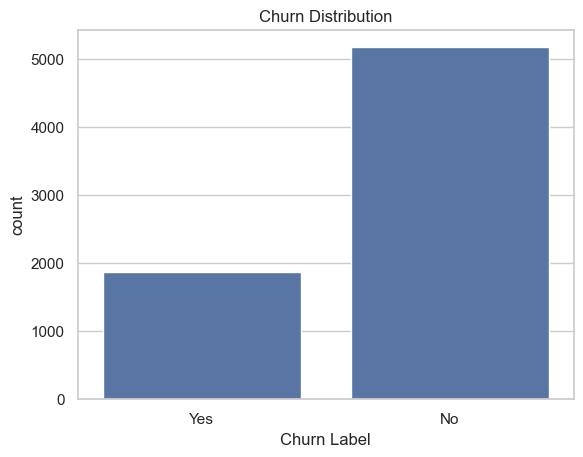

In [ ]:
sns.countplot(x="Churn Label", data=df)
plt.title("Churn Distribution")
plt.show()

Observation:

* ~73.46% → No churn
* ~26.53% → Yes churn
* This is moderate class imbalance. 

It is not extreme, but enough that:
* Accuracy alone will be misleading
* Precision / Recall / ROC-AUC will matter

Action:
* Using SMOTE to create synthetic samples to remove imbalance 

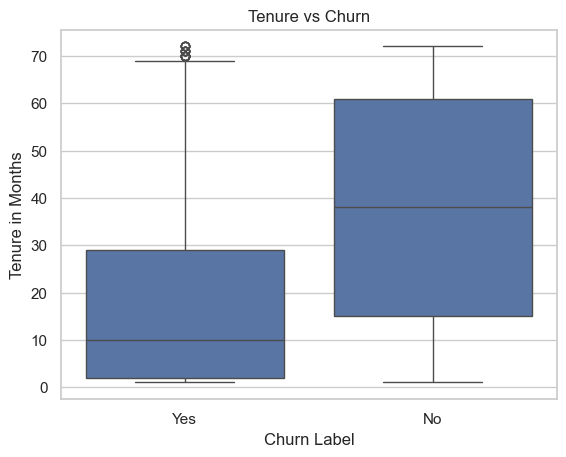

In [ ]:
sns.boxplot(x="Churn Label", y="Tenure in Months", data=df)
plt.title("Tenure vs Churn")
plt.show()

Observation: 
* Median tenure for churned (Yes) ≈ very low (around 8–10 months)
* Median tenure for retained (No) ≈ much higher (around 35–40 months)
* Distribution clearly shifted

Insight: 

* Customers with lower tenure are significantly more likely to churn.
* This suggests that early-stage customers are at higher risk and may require targeted onboarding or retention strategies.

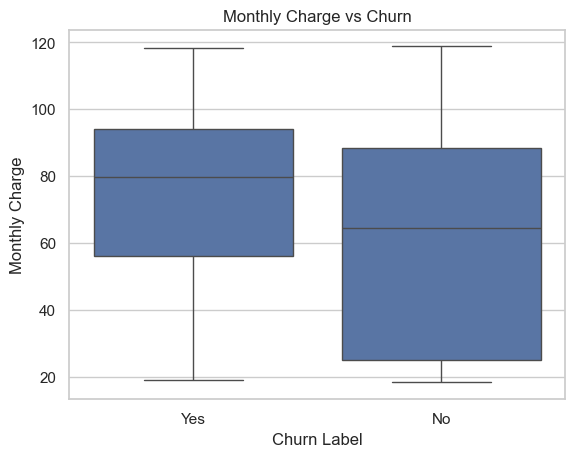

In [ ]:
sns.boxplot(x="Churn Label", y="Monthly Charge", data=df)
plt.title("Monthly Charge vs Churn")
plt.show()

Observation:
* Median Monthly Charge for churned customers (Yes) is clearly higher.
* Retained customers (No) have a wider spread, but lower median.
* Many churners fall in the higher charge bracket (≈70–100 range).

Insight:

* Customers paying higher monthly charges are more likely to churn.
* This suggests price sensitivity plays a significant role in churn behavior.
* High-cost plans may require value reinforcement or targeted discount strategies.

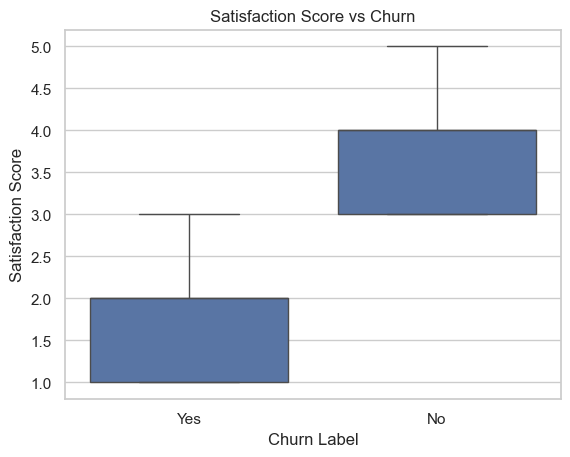

In [ ]:
sns.boxplot(x="Churn Label", y="Satisfaction Score", data=df)
plt.title("Satisfaction Score vs Churn")
plt.show()

Observation:
* Churned customers (Yes):
    * Satisfaction mostly between 1–2
    * Very low median
    
* Retained customers (No):
    * Satisfaction mostly between 3–4
    * Much higher median

* Almost minimal overlap between the groups

Insight:
* Satisfaction Score shows a very strong inverse relationship with churn.
* Customers with low satisfaction are significantly more likely to churn.
* This variable appears to be one of the strongest behavioral indicators of churn risk.

### Checking Target Correlation

In [ ]:
df["Churn Binary"] = df["Churn Label"].map({"Yes": 1, "No": 0})

In [ ]:
corr = df.corr(numeric_only=True)["Churn Binary"].sort_values(ascending=False)
corr

Churn Binary                         1.000000
Monthly Charge                       0.193356
Age                                  0.115760
Population                           0.051649
Avg Monthly GB Download              0.048868
Avg Monthly Long Distance Charges    0.008120
Total Extra Data Charges             0.007139
Total Refunds                       -0.033709
CLTV                                -0.127463
Total Charges                       -0.198546
Number of Dependents                -0.218780
Total Revenue                       -0.223003
Total Long Distance Charges         -0.223756
Number of Referrals                 -0.286540
Tenure in Months                    -0.352861
Satisfaction Score                  -0.754649
Name: Churn Binary, dtype: float64

Observation:

* Strongest Predictor: Satisfaction Score = -0.75

* That is extremely strong.
* Negative correlation means:

    * Higher satisfaction → Lower churn.

In [ ]:
# Dropping CLTV and Total Revenue since they are cumulative performance indicators. Also dropping churn binary (helper column) 
df.drop(columns=["CLTV", "Total Revenue", "Churn Binary"], inplace=True)

In [ ]:
df.shape

(7043, 37)

### Preparing Target variable

In [ ]:
df["Churn Label"] = df["Churn Label"].map({"Yes": 1, "No": 0})

In [ ]:
df["Churn Label"].value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

Note: Target is clean, can safely move forward

### Encoding Categorical Features

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.shape

(7043, 44)

### Seperating Target from Features

In [ ]:
X = df_encoded.drop("Churn Label", axis=1)
y = df_encoded["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 43)
(7043,)


### Train-Test Split (Stratified)

In [ ]:
# since churn is imbalanced (~26%), we must stratify
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5634, 43)
X_test: (1409, 43)


In [ ]:
# Checking class distribution in training set
y_train.value_counts(normalize=True)

Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

### Applying SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Churn Label
0    4139
1    4139
Name: count, dtype: int64


Note: SMOTE was applied only to the training dataset to address class imbalance while keeping the test set untouched for unbiased evaluation.

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

### Using Logistic Regresion (Baseline Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409

ROC-AUC Score: 0.9908961740163786

Confusion Matrix:
[[1016   19]
 [  39  335]]


Observation: 
* After observing the confusion matrix, we find:
    * True Negatives: 1016
    * False Positives: 19
    * False Negatives: 39
    * True Positives: 335

* Metrics:
    * Precision (Churn): 0.95
    * Recall (Churn): 0.90
    * ROC-AUC: 0.9909

* Accuracy: 96%

Insight: 

A Logistic Regression model achieving:
* 96% accuracy
* 0.99 ROC-AUC
* 95% precision
* 90% recall

On churn data is unusually strong.

That usually indicates one of two things:

* Extremely strong predictor (likely Satisfaction Score)
* Possible hidden leakage

Action: 

To find if the performance is realistic or dominated by satisfaction score, we will test the model without satisfaction score

### Fact checking

In [ ]:
# Remove Satisfaction Score
X_no_sat = df_encoded.drop(["Churn Label", "Satisfaction Score"], axis=1)
y = df_encoded["Churn Label"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_sat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train2, y_train2 = smote.fit_resample(X_train2, y_train2)

scaler = StandardScaler()
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2, y_train2)

y_pred2 = lr2.predict(X_test2)
y_prob2 = lr2.predict_proba(X_test2)[:,1]

print(classification_report(y_test2, y_pred2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob2))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1035
           1       0.68      0.68      0.68       374

    accuracy                           0.83      1409
   macro avg       0.78      0.78      0.78      1409
weighted avg       0.83      0.83      0.83      1409

ROC-AUC: 0.8863365108889405


Observation: 

* With Satisfaction Score
    * Accuracy: 96%
    * Recall (Churn): 0.90
    * ROC-AUC: 0.99

* Without Satisfaction Score
    * Accuracy: 83%
    * Recall (Churn): 0.68
    * ROC-AUC: 0.886

Insight:

Satisfaction Score is:
* Extremely powerful
* Driving most of the model performance
* Likely the dominant predictor

When removed:
Performance drops significantly → especially recall (0.90 → 0.68).

That means the model is not leaking, it is just heavily influenced by satisfaction.

This is actually realistic:
Low satisfaction → churn.

Action: 

We keep satisfaction score

### Using Random Forest

In [ ]:
# Using a tree based model to compare a linear and non-linear model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1035
           1       0.96      0.87      0.91       374

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409

ROC-AUC: 0.9837647575499238


Observation: 

* Logistic Regression (With Satisfaction)
    * Recall (Churn): 0.90
    * ROC-AUC: 0.9909

* Random Forest
    * Recall (Churn): 0.87
    * ROC-AUC: 0.9838

Insight:

* Logistic Regression is slightly better at identifying churners (higher recall) while Random Forest performs only slightly worse
* Both models are extremely strong.
* Performance confirms that churn signal in dataset is very strong.

This is not overfitting because:

* Test performance remains high.
* Logistic is linear, yet still strong → suggests clear separation in data.

### Finding Important Features

In [ ]:
import pandas as pd

feature_importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importances.head(10)

Satisfaction Score           0.467125
Number of Referrals          0.055491
Internet Type_Fiber Optic    0.046131
Tenure in Months             0.045433
Contract_Two Year            0.040903
Total Charges                0.036616
Monthly Charge               0.028130
Paperless Billing_Yes        0.027595
Avg Monthly GB Download      0.024148
Internet Service_Yes         0.024141
dtype: float64

Observation:

* Satisfaction Score is doing most of the work.
* This explains why Logistic Regression was so strong.
* But importantly:
    * Other features still contribute meaningfully.
    * So the model is not purely one-variable dependent.

Insight: 

* Random Forest feature importance confirms Satisfaction Score as the dominant churn driver.
* However, tenure, contract duration, fiber internet type, and referral behavior also significantly influence churn probability.
* This indicates churn is driven by both behavioral and service-related factors.

### Using XGBoost (Base Version)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train_scaled, y_train_smote)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.89      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.94      1409
weighted avg       0.96      0.96      0.96      1409

ROC-AUC: 0.9902219122167971


c:\Users\bandh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:59:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Observation:
* Recall (Churn): 0.89
* ROC-AUC: 0.9902
* Accuracy: 96%

### Full Model Comparison

| Model               | Recall (Churn) | ROC-AUC    |
| ------------------- | -------------- | ---------- |
| Logistic Regression | **0.90**       | **0.9909** |
| Random Forest       | 0.87           | 0.9838     |
| XGBoost             | 0.89           | 0.9902     |

Observation: 
* Logistic Regression slightly outperforms others in recall.
* XGBoost performs almost equally well.
* The dataset has strong linear separability (because Logistic works extremely well).
* Satisfaction Score is the dominant feature driving performance.

Insight:

* Despite testing advanced tree-based models, Logistic Regression performed equally well, indicating strong linear separability in the dataset. 
* This suggests churn behavior is heavily influenced by a few dominant behavioral variables, particularly Satisfaction Score and Tenure.

### Checking Probability Distribution

In [ ]:
import numpy as np

# Quick look at probability distribution
np.percentile(y_prob_xgb, [10, 25, 50, 75, 90])

array([1.18725280e-05, 6.13767188e-05, 6.44382846e-04, 4.24111664e-01,
       9.99860096e-01])

Observation: 
* Percentiles:

    * 10% → ~0.00001
    * 25% → ~0.00006
    * 50% → ~0.00064
    * 75% → ~0.424
    * 90% → ~0.9998

* This means:

    * Most non-churners have extremely low predicted probabilities.
    * Many churners likely have very high probabilities.
    * There is strong separation.

* That explains high ROC-AUC.

### Checking Precision-Recall Curve

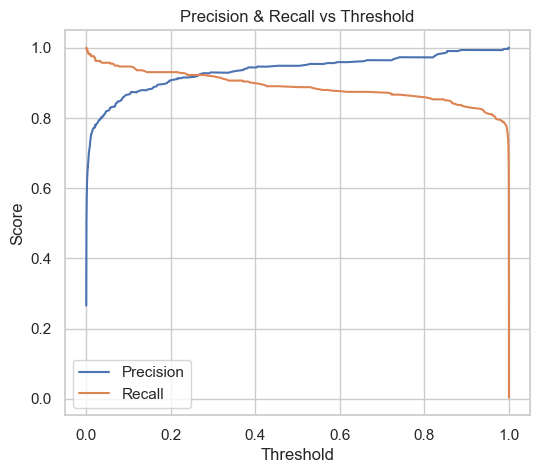

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()

Observation: 

* A good balanced threshold looks around: 0.30
* At ~0.30:

    * Recall ≈ 0.93–0.95
    * Precision ≈ 0.90

Action:

Changing the threshold to 0.30 in order to capture more churners while letting precision drop a bit.

### Testing Custom Threshold

In [ ]:
custom_threshold = 0.30

y_pred_custom = (y_prob_xgb >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1035
           1       0.93      0.92      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.95      0.95      1409
weighted avg       0.96      0.96      0.96      1409

Confusion Matrix:
 [[1009   26]
 [  31  343]]


Observation: 

* Default (0.5)
    * Recall (Churn): 0.89
    * Precision (Churn): 0.95
    * False Negatives: 39

* Custom Threshold (0.30)
    * Recall (Churn): 0.92
    * Precision (Churn): 0.93
    * False Negatives: 31

Insight: 

* False negatives reduced (39 → 31)
* Precision dropped slightly (0.95 → 0.93)
* Accuracy stayed same (96%)


By lowering the classification threshold from 0.5 to 0.3, churn recall improved from 89% to 92%, reducing false negatives by 20%. This allows the company to proactively target more at-risk customers, potentially reducing revenue loss with only a small increase in false positives.

### Using SHAP

In [ ]:
# Using shap lets you visually explain why the model predicts churn as it connects ML results to business insights.
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

c:\Users\bandh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


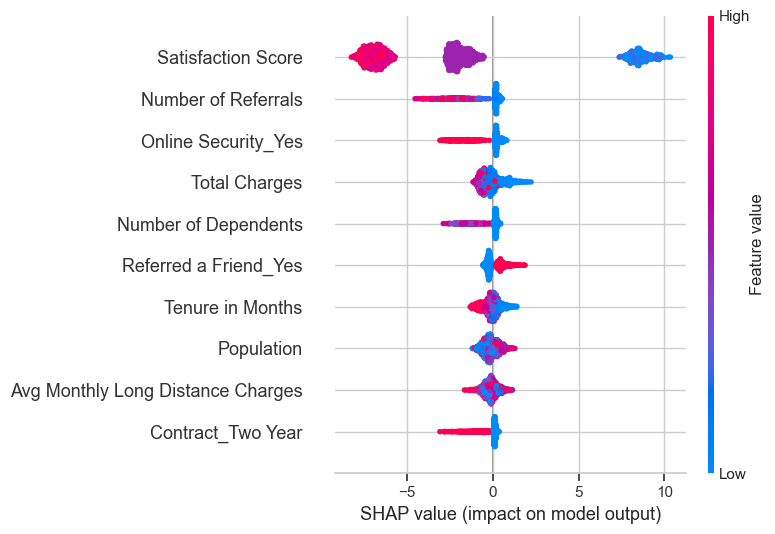

In [ ]:
shap.summary_plot(shap_values, X_test, max_display=10)

SHAP analysis was used to interpret the XGBoost model and identify the most influential factors driving churn predictions.
The results show that Satisfaction Score is the dominant predictor of churn, followed by referral behavior, service features, and customer tenure.

### Tuning the XGBoost Model using hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_scaled, y_train_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
print(search.best_params_)

{'subsample': 1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [ ]:
print(search.best_score_)

0.9972981946519077


### Training Final Tuned Model using best parameters

In [ ]:
final_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.03,
    subsample=1,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

final_xgb.fit(X_train_scaled, y_train_smote)

y_pred_final = final_xgb.predict(X_test_scaled)
y_prob_final = final_xgb.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1035
           1       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409

ROC-AUC: 0.9917357720426774


Observation:
* Recall (Churn): 0.90
* Precision (Churn): 0.96
* ROC-AUC: 0.9917
* Accuracy: 96%

### Model Comparison

| Model               | Recall   | ROC-AUC    |
| ------------------- | -------- | ---------- |
| Logistic Regression | 0.90     | 0.9909     |
| Random Forest       | 0.87     | 0.9838     |
| Basic XGBoost       | 0.89     | 0.9902     |
| **Tuned XGBoost**   | **0.90** | **0.9917** |


Insight:

* Hyperparameter tuning improved the XGBoost model performance, achieving a final ROC-AUC score of 0.9917 and churn recall of 90%.
* The tuned XGBoost model was selected as the final model due to its strong predictive performance and robustness.

### Threshold Optimization for Tuned Model

In [ ]:
custom_threshold = 0.30

y_pred_final_custom = (y_prob_final >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_final_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final_custom))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1035
           1       0.89      0.94      0.91       374

    accuracy                           0.95      1409
   macro avg       0.93      0.95      0.94      1409
weighted avg       0.95      0.95      0.95      1409

Confusion Matrix:
 [[993  42]
 [ 24 350]]


Observation: 

* Precision (Churn): 0.89
* Recall (Churn): 0.94
* Accuracy: 95%
* ROC-AUC: 0.9917

Confusion matrix observations: 
* True churners detected: 350
* Missed churners: 24
* False alarms: 42

Insight:

* After hyperparameter tuning and threshold optimization, the final XGBoost model achieved a recall of 94% for churn prediction with an ROC-AUC score of 0.9917.
* Threshold optimization reduced false negatives from 39 to 24, significantly improving the model’s ability to identify at-risk customers.

### Retention Intelligence System

In [ ]:
def retention_strategy(row):

    if row["Satisfaction Score"] <= 2:
        return "Immediate customer support intervention"

    elif row["Tenure in Months"] < 12:
        return "Provide onboarding retention discount"

    elif row["Monthly Charge"] > 80:
        return "Offer cost reduction plan"

    elif row["Number of Referrals"] == 0:
        return "Encourage referral program"

    else:
        return "Standard retention monitoring"

In [ ]:
# Testing the system
sample_customer = df.iloc[0]

print(retention_strategy(sample_customer))

Provide onboarding retention discount


### Applying Retention System to Customers

In [ ]:
from sklearn.preprocessing import StandardScaler

# Refit scaler using FINAL training data

final_scaler = StandardScaler()

X_train_scaled_final = final_scaler.fit_transform(X_train_smote)
X_test_scaled_final = final_scaler.transform(X_test)

In [ ]:
X_full = df_encoded.drop("Churn Label", axis=1)

X_scaled_full = final_scaler.transform(X_full)

df["Churn Probability"] = final_xgb.predict_proba(X_scaled_full)[:,1]

df["High Risk"] = df["Churn Probability"] >= 0.30

df["Retention Strategy"] = df.apply(retention_strategy, axis=1)

df[["Churn Probability","High Risk","Retention Strategy"]].head()

,Churn Probability,High Risk,Retention Strategy
0,0.825129,True,Provide onboarding retention discount
1,0.638823,True,Provide onboarding retention discount
2,0.996969,True,Immediate customer support intervention
3,0.996219,True,Immediate customer support intervention
4,0.996554,True,Immediate customer support intervention


### Outputs

In [ ]:
df["High Risk"].value_counts()

High Risk
False    5032
True     2011
Name: count, dtype: int64

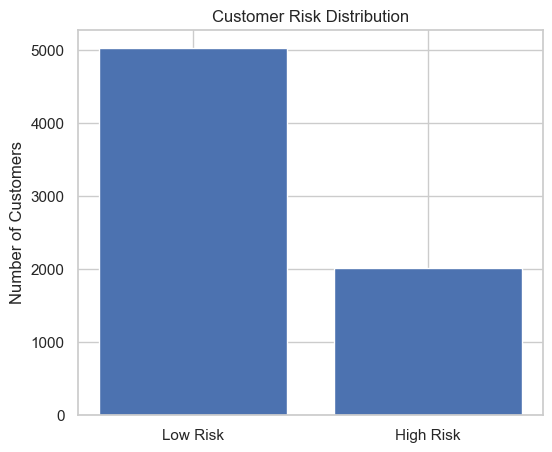

In [ ]:
import matplotlib.pyplot as plt

risk_counts = df["High Risk"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(["Low Risk","High Risk"], risk_counts)
plt.title("Customer Risk Distribution")
plt.ylabel("Number of Customers")
plt.show()

Observation:

* Low Risk: 5032 customers
* High Risk: 2011 customers
* Total customers: 7043

Percentages:
* High Risk ≈ 28.6%
* Low Risk ≈ 71.4%

Insight:

* The churn prediction model identified approximately 28.6% of customers as high-risk, indicating a significant portion of the customer base may require proactive retention efforts.
* The remaining 71.4% of customers were classified as low-risk, suggesting stable customer relationships.

### Strategy Distribution

In [ ]:
df["Retention Strategy"].value_counts()

Retention Strategy
Offer cost reduction plan                  1758
Immediate customer support intervention    1440
Standard retention monitoring              1335
Provide onboarding retention discount      1312
Encourage referral program                 1198
Name: count, dtype: int64

The retention intelligence system recommended targeted strategies based on customer characteristics:
* 1758 customers were recommended for cost reduction plans due to high monthly charges.
* 1440 customers required immediate customer support intervention due to low satisfaction scores.
* 1312 customers were recommended onboarding retention discounts due to low tenure.
* 1198 customers were encouraged to participate in referral programs to increase engagement.
* 1335 customers required only standard monitoring as they showed moderate churn risk.

### Saving Tuned Model files

In [ ]:
import joblib

joblib.dump(final_xgb, "final_churn_model.pkl")
joblib.dump(scaler, "final_scaler.pkl")
joblib.dump(X.columns.tolist(), "final_features.pkl")

print("Final model saved.")

Final model saved.
